# KidLit-Gold · Adjudication & IAA Statistics

This notebook reproduces the adjudication statistics reported in the paper
*“KidLit by Numbers: A Domain-Specific Annotation Methodology for Sentiment
and NER in Russian Children's Literature 0+”* from the files released in this repository:

- `../adjudication/adjudication_log.csv` — the complete adjudication log;
- `../gold_annotations/kidlit_gold_annotations.jsonl` — gold-standard spans (offsets + labels, no text);
- `../metadata/corpus_metadata.csv` — book-level metadata.

Sections and their counterparts in the paper:

| Notebook section | Paper |
|---|---|
| 2. Summary by disagreement type | Table 2, Fig. 1 |
| 3. New vs. existing precedents | unpublished |
| 4. NER label-disagreement clusters | unpublished |
| 5. Missed-entity asymmetry | unpublished |
| 6. Sentiment disagreement structure | Table 5, Fig. 2 |
| 7. Final labels of adjudicated sentiment cases | §5.3 |
| 8. RUS-O vs RUS-T (processed subset) | §5.1, §5.3, §6 |
| 9. Corpus-level counts from the gold annotation | Table 1 (annotation rows) |

**Note.** Adjudication is ongoing; the log grows with each release. All statistics below are
computed on rows with `valid == True` and reflect the log version shipped with this repository.

In [ ]:
import json
import pandas as pd

pd.set_option('display.width', 120)
pd.set_option('display.max_colwidth', 60)

LOG_PATH  = '../adjudication/adjudication_log.csv'
GOLD_PATH = '../gold_annotations/kidlit_gold_annotations.jsonl'
META_PATH = '../metadata/corpus_metadata.csv'

TYPE_ORDER = ['Sentiment_label', 'NER_missed_by_A', 'NER_missed_by_B', 'NER_label']
TYPE_NAMES = {
    'Sentiment_label': 'Sentiment (label)',
    'NER_missed_by_A': 'NER: missed by annotator A',
    'NER_missed_by_B': 'NER: missed by annotator B',
    'NER_label':       'NER: label on coinciding span',
}

## 1. Load the adjudication log

Rows with `valid == False` (known data-entry defects, see the repository README) are excluded
from all statistics, exactly as in the paper.

In [ ]:
log = pd.read_csv(LOG_PATH)
n_raw = len(log)
adj = log[log['valid']].copy()
books = sorted(adj['book_id'].unique())
print(f'Rows in the log: {n_raw}; valid decisions: {len(adj)}')
print(f'Books covered: {len(books)} '
      f'({sum(b.startswith("RUS-O") for b in books)} RUS-O, '
      f'{sum(b.startswith("RUS-T") for b in books)} RUS-T)')
books

Rows in the log: 998; valid decisions: 996
Books covered: 13 (10 RUS-O, 3 RUS-T)


['RUS-O_long_01',
 'RUS-O_long_02',
 'RUS-O_long_03',
 'RUS-O_long_04',
 'RUS-O_long_05',
 'RUS-O_medium_01',
 'RUS-O_medium_02',
 'RUS-O_medium_03',
 'RUS-O_medium_04',
 'RUS-O_medium_05',
 'RUS-T_long_01',
 'RUS-T_long_02',
 'RUS-T_long_03']

## 2. Summary by disagreement type — Table 2 / Fig. 1

In [ ]:
def fmt(n, total):
    return f'{n} ({n / total * 100:.1f}%)'

rows = []
for t in TYPE_ORDER:
    sub = adj[adj['type'] == t]
    fav = sub['resolved_in_favor_of'].value_counts()
    rows.append({
        'Disagreement type': TYPE_NAMES[t],
        'n': len(sub),
        '%': round(len(sub) / len(adj) * 100, 1),
        'In favor of A':   fmt(fav.get('A', 0), len(sub)),
        'In favor of B':   fmt(fav.get('B', 0), len(sub)),
        'Neither version': fmt(fav.get('neither', 0), len(sub)),
    })
fav_all = adj['resolved_in_favor_of'].value_counts()
rows.append({
    'Disagreement type': 'Total', 'n': len(adj), '%': 100.0,
    'In favor of A':   fmt(fav_all.get('A', 0), len(adj)),
    'In favor of B':   fmt(fav_all.get('B', 0), len(adj)),
    'Neither version': fmt(fav_all.get('neither', 0), len(adj)),
})
table4 = pd.DataFrame(rows)
table4

,Disagreement type,n,%,In favor of A,In favor of B,Neither version
0,Sentiment (label),594,59.6,351 (59.1%),235 (39.6%),8 (1.3%)
1,NER: missed by annotator A,248,24.9,125 (50.4%),90 (36.3%),33 (13.3%)
2,NER: missed by annotator B,88,8.8,85 (96.6%),2 (2.3%),1 (1.1%)
3,NER: label on coinciding span,66,6.6,8 (12.1%),43 (65.2%),15 (22.7%)
4,Total,996,100.0,569 (57.1%),370 (37.1%),57 (5.7%)


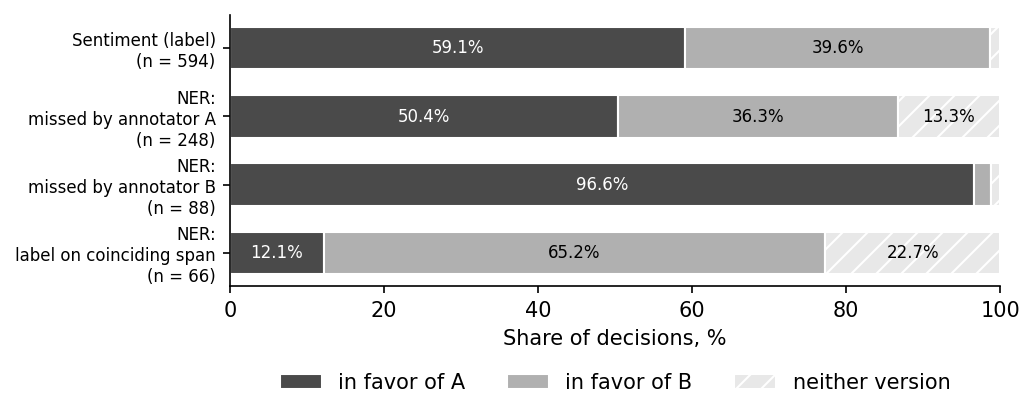

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

ct  = pd.crosstab(adj['type'], adj['resolved_in_favor_of']).reindex(TYPE_ORDER)
pct = ct.div(ct.sum(axis=1), axis=0) * 100
labels = [f"{TYPE_NAMES[t].replace(': ', ':\n')}\n(n = {ct.loc[t].sum()})" for t in TYPE_ORDER]

fig, ax = plt.subplots(figsize=(7, 3), dpi=150)
left   = np.zeros(len(TYPE_ORDER))
style  = {'A': '#4a4a4a', 'B': '#b0b0b0', 'neither': '#e8e8e8'}
names  = {'A': 'in favor of A', 'B': 'in favor of B', 'neither': 'neither version'}
y = np.arange(len(TYPE_ORDER))[::-1]
for cat in ['A', 'B', 'neither']:
    vals = pct[cat].values
    ax.barh(y, vals, left=left, color=style[cat], edgecolor='white',
            hatch='//' if cat == 'neither' else '', label=names[cat], height=0.62)
    for yi, v, l in zip(y, vals, left):
        if v > 6:
            ax.text(l + v / 2, yi, f'{v:.1f}%', ha='center', va='center',
                    fontsize=8, color='white' if cat == 'A' else 'black')
    left += vals
ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=8)
ax.set_xlim(0, 100); ax.set_xlabel('Share of decisions, %')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=3, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig1_adjudication_decisions.png', bbox_inches='tight')
plt.show()

## 3. New vs. existing precedents (unpublished)

In [ ]:
new_total = int(adj['new_precedent'].sum())
print(f'New precedents: {new_total} ({new_total/len(adj)*100:.1f}%); '
      f'existing rules applied: {len(adj)-new_total} ({(len(adj)-new_total)/len(adj)*100:.1f}%)\n')
by_type = pd.crosstab(adj['type'], adj['new_precedent']).reindex(TYPE_ORDER)
by_type.columns = ['existing rule', 'new precedent']
by_type['% new'] = (by_type['new precedent'] / by_type.sum(axis=1) * 100).round(1)
by_type

New precedents: 514 (51.6%); existing rules applied: 482 (48.4%)



,existing rule,new precedent,% new
type,,,
Sentiment_label,136,458,77.1
NER_missed_by_A,210,38,15.3
NER_missed_by_B,70,18,20.5
NER_label,66,0,0.0


## 4. NER label-disagreement clusters (unpublished)

The 66 label mismatches on coinciding spans fall into three clusters; the largest
(PER_NAME ↔ PER_ROLE) splits into two subtypes distinguished by precedent:
unique authorial names (A-1/A-3) vs. compound names (A-6).

In [ ]:
ner = adj[adj['type'] == 'NER_label'].copy()

def cluster(row):
    pair = frozenset([row['label_A'], row['label_B']])
    if pair == frozenset(['PER_NAME', 'PER_ROLE']):   return 'PER_NAME <-> PER_ROLE'
    if pair == frozenset(['PER_NAME', 'PER_FAMILY']): return 'PER_NAME <-> PER_FAMILY'
    return 'PER_ROLE <-> PER_FAMILY'

ner['cluster'] = ner.apply(cluster, axis=1)
ner['subtype'] = np.where(ner['cluster'] != 'PER_NAME <-> PER_ROLE', '-',
                 np.where(ner['precedent_id'].astype(str).str.startswith('A-6'),
                          'compound names (A-6)', 'authorial names (A-1/A-3)'))

summary = (ner.groupby(['cluster', 'subtype'])
              .agg(n=('case_id', 'size'),
                   favor_A=('resolved_in_favor_of', lambda s: (s == 'A').sum()),
                   favor_B=('resolved_in_favor_of', lambda s: (s == 'B').sum()),
                   neither=('resolved_in_favor_of', lambda s: (s == 'neither').sum()))
              .reset_index())
summary['% of NER_label'] = (summary['n'] / len(ner) * 100).round(1)
print(f'NER label disagreements: {len(ner)}')
summary

NER label disagreements: 66


,cluster,subtype,n,favor_A,favor_B,neither,% of NER_label
0,PER_NAME <-> PER_FAMILY,-,11,2,9,0,16.7
1,PER_NAME <-> PER_ROLE,authorial names (A-1/A-3),28,1,27,0,42.4
2,PER_NAME <-> PER_ROLE,compound names (A-6),18,0,3,15,27.3
3,PER_ROLE <-> PER_FAMILY,-,9,5,4,0,13.6


In [ ]:
print('Final labels within each cluster:')
ner.groupby('cluster')['decision'].value_counts().unstack(fill_value=0)

Final labels within each cluster:


decision,PER_FAMILY,PER_NAME,PER_ROLE
cluster,,,
PER_NAME <-> PER_FAMILY,1,10,0
PER_NAME <-> PER_ROLE,0,45,1
PER_ROLE <-> PER_FAMILY,6,0,3


## 5. Missed-entity asymmetry (unpublished)

In [ ]:
for t, who in [('NER_missed_by_B', 'B missed, A marked'), ('NER_missed_by_A', 'A missed, B marked')]:
    sub = adj[adj['type'] == t]
    fav = sub['resolved_in_favor_of'].value_counts()
    print(f'{TYPE_NAMES[t]} ({who}): n = {len(sub)}')
    for k in ['A', 'B', 'neither']:
        print(f'   {k:>8}: {fmt(fav.get(k, 0), len(sub))}')

NER: missed by annotator B (B missed, A marked): n = 88
          A: 85 (96.6%)
          B: 2 (2.3%)
    neither: 1 (1.1%)
NER: missed by annotator A (A missed, B marked): n = 248
          A: 125 (50.4%)
          B: 90 (36.3%)
    neither: 33 (13.3%)


## 6. Sentiment disagreement structure — Table 3 / Fig. 2

In [ ]:
sent = adj[adj['type'] == 'Sentiment_label'].copy()
NEU = '0 NEUTRAL'
sent['kind'] = np.where((sent['label_A'] == NEU) | (sent['label_B'] == NEU),
                        'neutral vs valenced', 'opposite polarity')

rows, n = [], len(sent)
nv, opp = sent[sent['kind'] == 'neutral vs valenced'], sent[sent['kind'] == 'opposite polarity']
rows.append(('Neutral <-> valenced label (0<->+1 or 0<->-1)', len(nv), round(len(nv)/n*100, 1)))
for a, b in [('+1 POSITIVE', NEU), (NEU, '+1 POSITIVE'), ('-1 NEGATIVE', NEU), (NEU, '-1 NEGATIVE')]:
    k = ((sent['label_A'] == a) & (sent['label_B'] == b)).sum()
    rows.append((f'   incl. A: {a}, B: {b}', k, round(k/n*100, 1)))
rows.append(('Opposite polarity (+1<->-1)', len(opp), round(len(opp)/n*100, 1)))
for a, b in [('-1 NEGATIVE', '+1 POSITIVE'), ('+1 POSITIVE', '-1 NEGATIVE')]:
    k = ((sent['label_A'] == a) & (sent['label_B'] == b)).sum()
    rows.append((f'   incl. A: {a}, B: {b}', k, round(k/n*100, 1)))
table5 = pd.DataFrame(rows, columns=['Disagreement type', 'n', f'% of {n}'])
table5

,Disagreement type,n,% of 594
0,Neutral <-> valenced label (0<->+1 or 0<->-1),547,92.1
1,"incl. A: +1 POSITIVE, B: 0 NEUTRAL",213,35.9
2,"incl. A: 0 NEUTRAL, B: +1 POSITIVE",134,22.6
3,"incl. A: -1 NEGATIVE, B: 0 NEUTRAL",127,21.4
4,"incl. A: 0 NEUTRAL, B: -1 NEGATIVE",73,12.3
5,Opposite polarity (+1<->-1),47,7.9
6,"incl. A: -1 NEGATIVE, B: +1 POSITIVE",31,5.2
7,"incl. A: +1 POSITIVE, B: -1 NEGATIVE",16,2.7


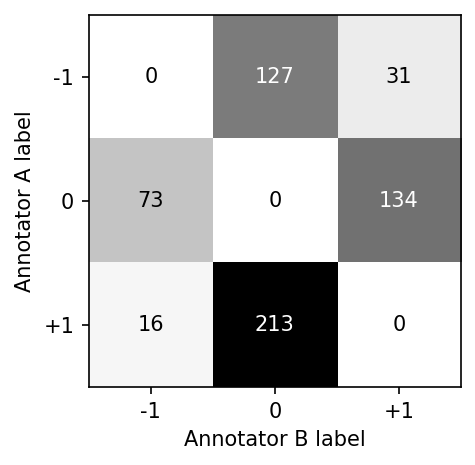

label_B,-1 NEGATIVE,0 NEUTRAL,+1 POSITIVE
label_A,,,
-1 NEGATIVE,0,127,31
0 NEUTRAL,73,0,134
+1 POSITIVE,16,213,0


In [ ]:
order = ['-1 NEGATIVE', NEU, '+1 POSITIVE']
mat = pd.crosstab(sent['label_A'], sent['label_B']).reindex(index=order, columns=order).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(3.6, 3.2), dpi=150)
ax.imshow(mat.values, cmap='Greys', vmin=0, vmax=mat.values.max())
short = ['-1', '0', '+1']
for i in range(3):
    for j in range(3):
        v = mat.values[i, j]
        ax.text(j, i, str(v), ha='center', va='center',
                color='white' if v > mat.values.max() * 0.55 else 'black')
ax.set_xticks(range(3)); ax.set_xticklabels(short)
ax.set_yticks(range(3)); ax.set_yticklabels(short)
ax.set_xlabel('Annotator B label'); ax.set_ylabel('Annotator A label')
plt.tight_layout()
plt.savefig('fig2_sentiment_confusion.png', bbox_inches='tight')
plt.show()
mat

## 7. Final labels of the adjudicated sentiment cases (§5.3)

In [ ]:
final = sent['decision'].value_counts()
for lab in ['+1 POSITIVE', '-1 NEGATIVE', NEU]:
    print(f'{lab:>12}: {fmt(final.get(lab, 0), len(sent))}')

 +1 POSITIVE: 374 (63.0%)
 -1 NEGATIVE: 152 (25.6%)
   0 NEUTRAL: 68 (11.4%)


## 8. RUS-O vs RUS-T on the processed subset (§5.1, §5.3, §6)

With only part of the RUS-T subgroup adjudicated, these are preliminary observations,
not subgroup conclusions.

In [ ]:
adj['group'] = np.where(adj['book_id'].str.startswith('RUS-T'), 'RUS-T', 'RUS-O')
for g, sub in adj.groupby('group'):
    s = sub[sub['type'] == 'Sentiment_label']
    opp = ((s['label_A'] != NEU) & (s['label_B'] != NEU)).sum()
    nercases = sub[sub['type'].str.startswith('NER')]
    print(f'{g}: {len(sub)} decisions over {sub.book_id.nunique()} books | '
          f'sentiment n = {len(s)}, opposite-polarity: {opp} ({opp/len(s)*100:.1f}%) | '
          f'NER cases: {len(nercases)}, resolved by existing rules: '
          f'{int((~nercases.new_precedent).sum())}')

RUS-O: 749 decisions over 10 books | sentiment n = 467, opposite-polarity: 34 (7.3%) | NER cases: 282, resolved by existing rules: 237
RUS-T: 247 decisions over 3 books | sentiment n = 127, opposite-polarity: 13 (10.2%) | NER cases: 120, resolved by existing rules: 109


## 9. Corpus-level counts from the gold annotation (Table 1, annotation rows)

Computed from the released offsets-and-labels file; annotator A's counts are the ones
reported in the paper.

In [ ]:
gold = [json.loads(l) for l in open(GOLD_PATH, encoding='utf-8')]
meta = pd.read_csv(META_PATH)

recs = []
for r in gold:
    for span in r['ner']:
        recs.append({'annotator': r['annotator'], 'task': 'ner', 'label': span['label']})
    for span in r['sentiment']:
        recs.append({'annotator': r['annotator'], 'task': 'sentiment', 'label': span['label']})
g = pd.DataFrame(recs)

print('Entities / units per annotator:')
print(g.groupby(['annotator', 'task']).size().unstack(), '\n')

A = g[g['annotator'] == 'A']
print('Annotator A, NER label distribution:')
ner_d = A[A['task'] == 'ner']['label'].value_counts()
print(pd.DataFrame({'n': ner_d, '%': (ner_d / ner_d.sum() * 100).round(1)}), '\n')

print('Annotator A, sentiment label distribution:')
s_d = A[A['task'] == 'sentiment']['label'].value_counts()
print(pd.DataFrame({'n': s_d, '%': (s_d / s_d.sum() * 100).round(1)}), '\n')

print(f"Corpus totals from metadata: {meta['n_tokens'].sum():,} tokens (razdel), "
      f"{meta['n_sentences'].sum():,} sentence units (annotator B), {len(meta)} books")

Entities / units per annotator:
task        ner  sentiment
annotator                 
A          2562       3962
B          2784       3548 

Annotator A, NER label distribution:
               n     %
label                 
PER_ROLE    1504  58.7
PER_NAME     586  22.9
PER_FAMILY   472  18.4 

Annotator A, sentiment label distribution:
                n     %
label                  
0 NEUTRAL    1531  38.6
+1 POSITIVE  1374  34.7
-1 NEGATIVE  1057  26.7 

Corpus totals from metadata: 33,806 tokens (razdel), 3,548 sentence units (annotator B), 30 books


---
*Figures are saved next to this notebook as `fig1_adjudication_decisions.png` and
`fig2_sentiment_confusion.png`. Inter-annotator agreement coefficients (Cohen's κ for sentiment,
entity-level F1 for NER) require span alignment against the source texts and are therefore
computed in the annotation pipeline, not in this repository; the values are reported in the paper.*